# Random Forest
**Model:** Random Forest Regressor  
**Objective:** To build an ensemble learning model that captures non-linear relationships in the UAE car market, perform hyperparameter tuning, and extract feature importance to understand what drives car depreciation and value.

## 1. Environment Setup & Library Imports
We import the standard data science libraries, along with the `RandomForestRegressor`, hyperparameter tuning tools, and `joblib` to save our final model.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. Data Loading & Splitting
We msut load the preprocessed `uae_cars_cleaned.csv` and use the exact same `random_state=42` to ensure teh 70/15/15 train/validation/test split matches the baseline model perfectly. If the split is different, we cannot fairly compare our models.

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../data/uae_cars_cleaned.csv")

# Separate features (X) and target (y)
X = df.drop(['Price'], axis=1)
y = df['Price']


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Train set: (6227, 548)
Validation set: (1334, 548)
Test set: (1335, 548)


## 3. Default Random Forest Model
Before tuning, we will train a baseline Random Forest using the default 100 trees to see how much ensemble learning improves our accuracy compared to the Linear Regression model.

In [3]:
# Initialize and train default model
rf_default = RandomForestRegressor(n_estimators=100, random_state=42)
rf_default.fit(X_train, y_train)

# Evaluate on Validation set
y_pred_val_default = rf_default.predict(X_val)

print("--- Default Random Forest (Validation) ---")
print(f"RMSE: AED {np.sqrt(mean_squared_error(y_val, y_pred_val_default)):,.2f}")
print(f"MAE:  AED {mean_absolute_error(y_val, y_pred_val_default):,.2f}")
print(f"R²:   {r2_score(y_val, y_pred_val_default):.4f}")

--- Default Random Forest (Validation) ---
RMSE: AED 76,971.56
MAE:  AED 51,941.76
R²:   0.4873


## 4. Hyperparameter Tuning
To get the maximum performance out of our model, we will test different configurations of trees, depth, and split criteria. 

*Note: We are using `RandomizedSearchCV` instead of `GridSearchCV` to save computational time, as Random Forests can be very heavy to train on ~9,000 rows across a 5-fold cross-validation.*

In [17]:
# Define the parameter grid 
param_dist = {
    'n_estimators': [500, 800],
    'max_depth': [None, 40, 50],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'] 
}

# Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=100, # Number of random combinations to try
    cv=5,      # 5-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# Fit the random search model 
rf_random.fit(X_train, y_train)

print("\nBest Parameters found:")
print(rf_random.best_params_)

# Extract the best model
best_rf = rf_random.best_estimator_

C:\Users\wafee\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 24 is smaller than n_iter=100. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters found:
{'n_estimators': 800, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}


## 5. Feature Importance Analysis
One of the massive advantages of a Random Forest is its ability to rank exactly which features were mathematically most important in deciding the final price of the car. We will extract this data and plot the top 15 drivers of UAE car prices.

C:\Users\wafee\AppData\Local\Temp\ipykernel_18216\4032327854.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


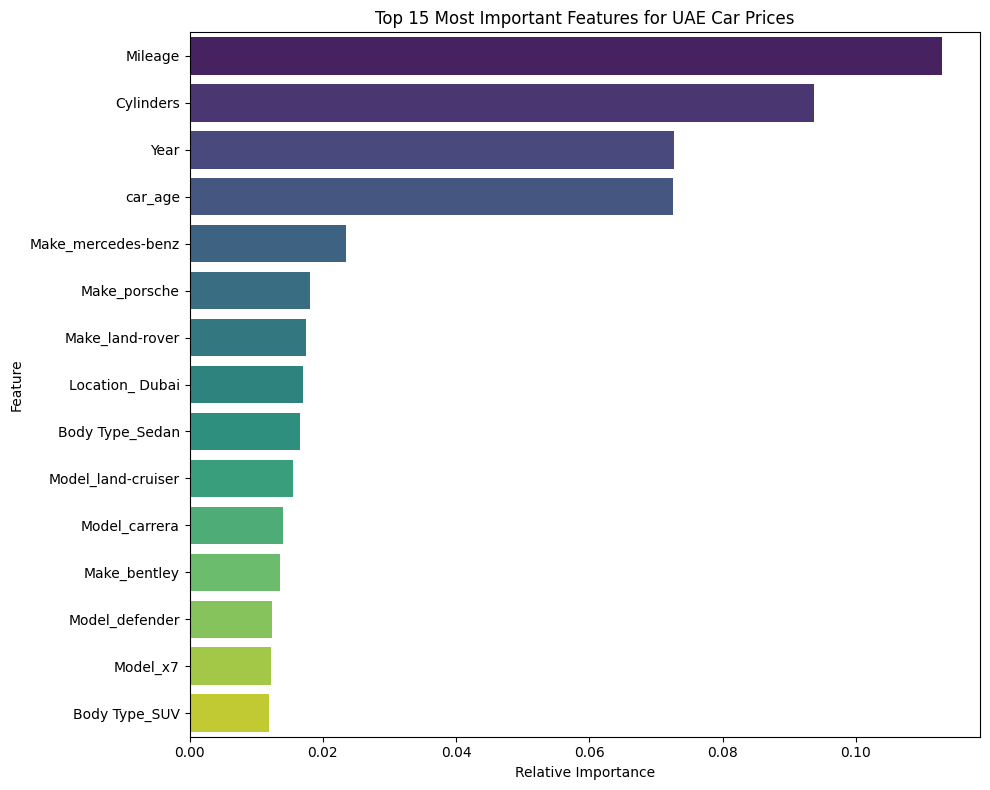

In [18]:
# Extract feature importances from the best model
importances = best_rf.feature_importances_

# Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

# Plot the Top 15 Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 15 Most Important Features for UAE Car Prices')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Final Evaluation & Visualizations
We will now evaluate our optimized model on the completely unseen Test Set, and generate the final visualization plots:
1. Actual vs. Predicted Prices
2. The Learning Curve (to ensure we aren't overfitting)

--- FINAL OPTIMIZED MODEL (Test Set) ---
RMSE: AED 73,906.72
MAE:  AED 51,804.69
R²:   0.5118



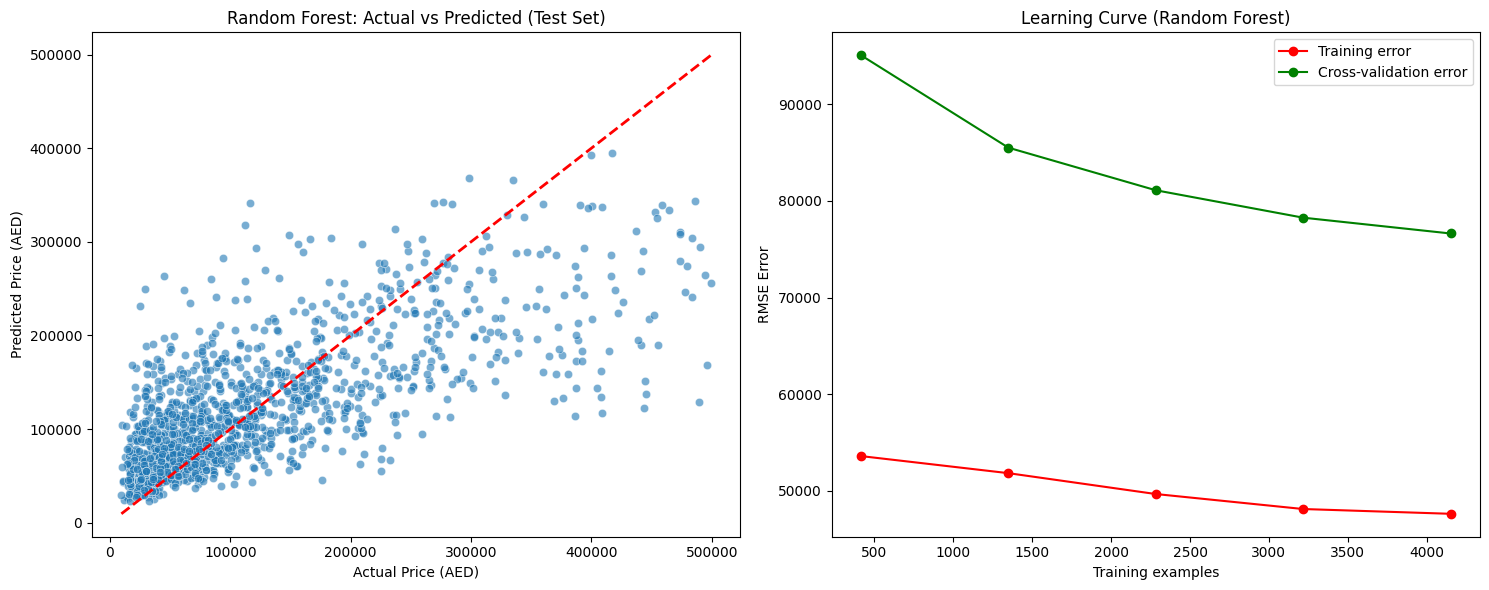

In [19]:
# Predict on the unseen Test Set
y_pred_test = best_rf.predict(X_test)

print("--- FINAL OPTIMIZED MODEL (Test Set) ---")
print(f"RMSE: AED {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
print(f"MAE:  AED {mean_absolute_error(y_test, y_pred_test):,.2f}")
print(f"R²:   {r2_score(y_test, y_pred_test):.4f}\n")

plt.figure(figsize=(15, 6))

# 1. Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title('Random Forest: Actual vs Predicted (Test Set)')

# 2. Learning Curve
plt.subplot(1, 2, 2)
train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X_train, y_train, cv=3, scoring='neg_mean_squared_error', 
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1)

train_scores_mean = np.sqrt(-train_scores.mean(axis=1))
test_scores_mean = np.sqrt(-test_scores.mean(axis=1))

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training error")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation error")
plt.xlabel("Training examples")
plt.ylabel("RMSE Error")
plt.title("Learning Curve (Random Forest)")
plt.legend(loc="best")

plt.tight_layout()
plt.show()

## 7. Model Export
We save the trained and optimized Random Forest model as a `.pkl` file in our `models/` directory so it can be accessed later without needing to be retrained.

In [20]:
# Save the model to the models directory
model_path = "../models/rf_model.pkl"
joblib.dump(best_rf, model_path)
print(f"Random Forest model successfully saved to {model_path}")

Random Forest model successfully saved to ../models/rf_model.pkl
